## Import Required Libraries
We'll import all necessary tools for:
- Data handling (pandas, numpy, librosa for audio processing)
- PyTorch for model training
- Visualization tools (matplotlib)
- Pretrained models from torchvision and transformers

In [1]:
import os
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.8.0+cu128
CUDA available: True
Using device: cuda


## Download and Load ESC-50 Dataset
The ESC-50 dataset contains 2,000 environmental audio recordings (50 classes, 40 clips per class, 5-second duration).
We'll use **fold 1 as validation** and the remaining folds (2-5) as training data.

In [2]:
URL = "https://github.com/karolpiczak/ESC-50/archive/refs/heads/master.zip"
ZIP_NAME = "ESC-50.zip"
DIR_NAME = "ESC-50-master"

if not os.path.exists(DIR_NAME):
    print("Downloading dataset...")
    urllib.request.urlretrieve(URL, ZIP_NAME)
    with zipfile.ZipFile(ZIP_NAME, 'r') as z:
        z.extractall(".")
    os.remove(ZIP_NAME)
    print("Dataset downloaded and extracted!")
else:
    print("Dataset already exists.")

DATA_PATH = os.path.join(DIR_NAME, "audio")
df = pd.read_csv(os.path.join(DIR_NAME, "meta/esc50.csv"))
print(f"\nDataset Loaded: {len(df)} samples, {df['target'].nunique()} classes.")
print(f"\nFirst few samples:")
display(df.head())

# Split data: fold 1 = validation, others = training
train_df = df[df['fold'] != 1].reset_index(drop=True)
val_df = df[df['fold'] == 1].reset_index(drop=True)
print(f"\nTraining samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Dataset already exists.

Dataset Loaded: 2000 samples, 50 classes.

First few samples:


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A



Training samples: 1600
Validation samples: 400


## Log-Mel Spectrogram Function
We'll create a function to convert audio waveforms into log-mel spectrograms with:
- **FFT size**: 2048
- **Hop length**: 512
- **Mel bins**: 128

In [3]:
def compute_logmel(audio_path, n_fft=2048, hop_length=512, n_mels=128):
    """
    Compute log-mel spectrogram from audio file.
    Returns a 3-channel image (duplicated across channels for pretrained models).
    """
    # Load audio
    y, sr = librosa.load(audio_path, sr=22050)
    
    # Compute mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    
    # Convert to log scale
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Normalize to [0, 1]
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min())
    
    # Convert to 3-channel image (duplicate for RGB)
    log_mel_3ch = np.stack([log_mel, log_mel, log_mel], axis=0)
    
    return log_mel_3ch

print("Log-mel spectrogram function created!")

Log-mel spectrogram function created!


## Visualize Sample Spectrogram
Let's visualize a random audio sample and its log-mel spectrogram representation.

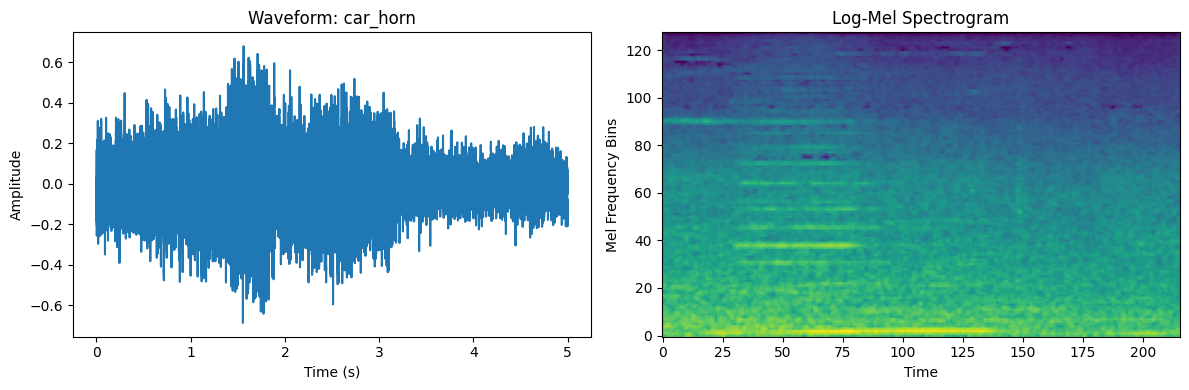

Sample: 2-42101-A-43.wav
Category: car_horn (class 43)
Spectrogram shape: (3, 128, 216)


In [4]:
# Pick a random sample
sample_idx = np.random.randint(len(train_df))
sample_row = train_df.iloc[sample_idx]
audio_path = os.path.join(DATA_PATH, sample_row['filename'])

# Load and compute log-mel
y, sr = librosa.load(audio_path, sr=22050)
log_mel = compute_logmel(audio_path)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Waveform
axes[0].plot(np.linspace(0, len(y)/sr, len(y)), y)
axes[0].set_title(f"Waveform: {sample_row['category']}")
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# Log-mel spectrogram
axes[1].imshow(log_mel[0], aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Log-Mel Spectrogram')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Mel Frequency Bins')

plt.tight_layout()
plt.show()

print(f"Sample: {sample_row['filename']}")
print(f"Category: {sample_row['category']} (class {sample_row['target']})")
print(f"Spectrogram shape: {log_mel.shape}")

## PyTorch Dataset Class
Create a custom dataset class to load audio files and convert them to log-mel spectrograms.

In [5]:
class ESC50Dataset(Dataset):
    def __init__(self, dataframe, data_path, transform=None):
        self.dataframe = dataframe
        self.data_path = data_path
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        audio_path = os.path.join(self.data_path, row['filename'])
        
        # Compute log-mel spectrogram
        log_mel = compute_logmel(audio_path)
        log_mel = torch.FloatTensor(log_mel)
        
        if self.transform:
            log_mel = self.transform(log_mel)
        
        label = row['target']
        return log_mel, label

# Create datasets and dataloaders
train_dataset = ESC50Dataset(train_df, DATA_PATH)
val_dataset = ESC50Dataset(val_df, DATA_PATH)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 100
Validation batches: 25


## Model 1: ResNet34
We'll use a pretrained ResNet34 from torchvision and fine-tune it on ESC-50 spectrograms.
The final layer will be replaced to output 50 classes.

In [6]:
print("=" * 60)
print("MODEL 1: ResNet34")
print("=" * 60)

# Load pretrained ResNet34
model_resnet34 = models.resnet34(pretrained=True)
model_resnet34.fc = nn.Linear(model_resnet34.fc.in_features, 50)  # 50 classes
model_resnet34 = model_resnet34.to(device)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet34.parameters(), lr=0.001)
num_epochs = 20

# Training history
resnet34_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training
    model_resnet34.train()
    train_loss, train_correct = 0.0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_resnet34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = train_correct / len(train_dataset)
    
    # Validation
    model_resnet34.eval()
    val_loss, val_correct = 0.0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_resnet34(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_dataset)
    
    # Save history
    resnet34_history['train_loss'].append(train_loss)
    resnet34_history['train_acc'].append(train_acc)
    resnet34_history['val_loss'].append(val_loss)
    resnet34_history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print(f"\nResNet34 Final Validation Accuracy: {resnet34_history['val_acc'][-1]:.4f}")

MODEL 1: ResNet34

Starting training...
Epoch 5/20 - Train Loss: 1.0597, Train Acc: 0.6625, Val Loss: 2.0606, Val Acc: 0.4625
Epoch 10/20 - Train Loss: 0.3022, Train Acc: 0.9100, Val Loss: 1.7289, Val Acc: 0.5500
Epoch 15/20 - Train Loss: 0.1592, Train Acc: 0.9475, Val Loss: 1.7864, Val Acc: 0.6000
Epoch 20/20 - Train Loss: 0.1126, Train Acc: 0.9688, Val Loss: 1.2583, Val Acc: 0.6950

ResNet34 Final Validation Accuracy: 0.6950


## ResNet34 Results Visualization
Plot training and validation loss/accuracy curves for ResNet34.

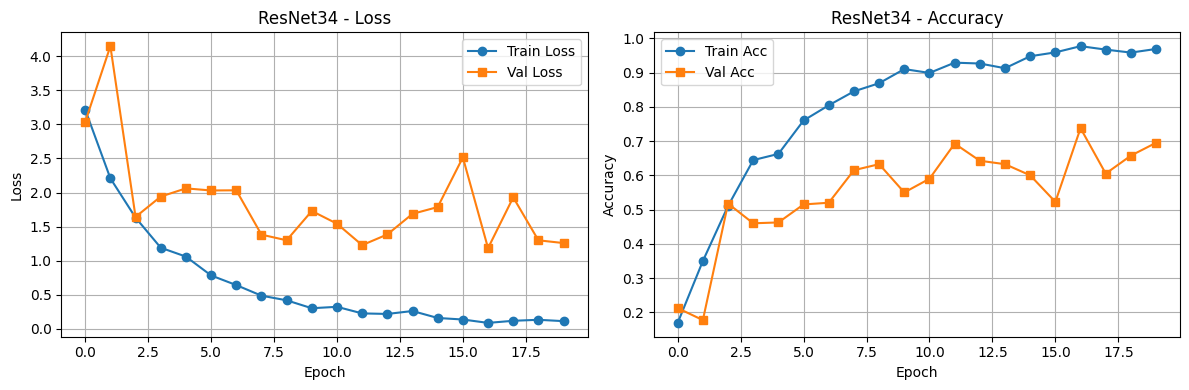

Best Validation Accuracy: 0.7375


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(resnet34_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(resnet34_history['val_loss'], label='Val Loss', marker='s')
axes[0].set_title('ResNet34 - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(resnet34_history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(resnet34_history['val_acc'], label='Val Acc', marker='s')
axes[1].set_title('ResNet34 - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Best Validation Accuracy: {max(resnet34_history['val_acc']):.4f}")

## Model 2: EfficientNet-B0
EfficientNet offers a better accuracy-to-efficiency ratio and works well on smaller datasets.
We'll use pretrained EfficientNet-B0 and fine-tune it.

In [8]:
print("=" * 60)
print("MODEL 2: EfficientNet-B0")
print("=" * 60)

# Load pretrained EfficientNet-B0
model_efficientnet = models.efficientnet_b0(pretrained=True)
model_efficientnet.classifier[1] = nn.Linear(model_efficientnet.classifier[1].in_features, 50)
model_efficientnet = model_efficientnet.to(device)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_efficientnet.parameters(), lr=0.001)
num_epochs = 20

# Training history
efficientnet_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training
    model_efficientnet.train()
    train_loss, train_correct = 0.0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_efficientnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = train_correct / len(train_dataset)
    
    # Validation
    model_efficientnet.eval()
    val_loss, val_correct = 0.0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_efficientnet(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_dataset)
    
    # Save history
    efficientnet_history['train_loss'].append(train_loss)
    efficientnet_history['train_acc'].append(train_acc)
    efficientnet_history['val_loss'].append(val_loss)
    efficientnet_history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print(f"\nEfficientNet Final Validation Accuracy: {efficientnet_history['val_acc'][-1]:.4f}")

MODEL 2: EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /teamspace/studios/this_studio/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 230MB/s]


Starting training...


Epoch 5/20 - Train Loss: 0.3968, Train Acc: 0.8756, Val Loss: 0.9746, Val Acc: 0.7475
Epoch 10/20 - Train Loss: 0.1770, Train Acc: 0.9537, Val Loss: 0.8974, Val Acc: 0.7525
Epoch 15/20 - Train Loss: 0.1550, Train Acc: 0.9544, Val Loss: 1.1861, Val Acc: 0.7550
Epoch 20/20 - Train Loss: 0.1103, Train Acc: 0.9706, Val Loss: 1.0720, Val Acc: 0.7400

EfficientNet Final Validation Accuracy: 0.7400


## EfficientNet Results Visualization
Plot training and validation loss/accuracy curves for EfficientNet-B0.

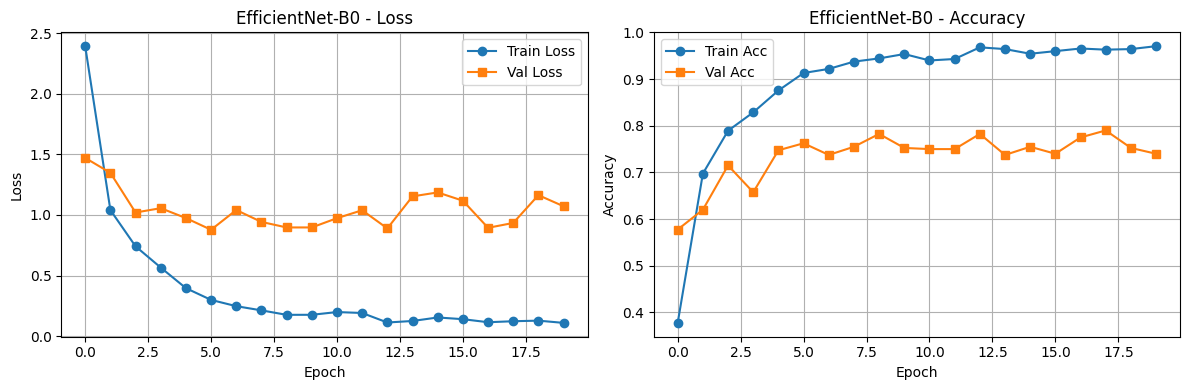

Best Validation Accuracy: 0.7900


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(efficientnet_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(efficientnet_history['val_loss'], label='Val Loss', marker='s')
axes[0].set_title('EfficientNet-B0 - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(efficientnet_history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(efficientnet_history['val_acc'], label='Val Acc', marker='s')
axes[1].set_title('EfficientNet-B0 - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Best Validation Accuracy: {max(efficientnet_history['val_acc']):.4f}")

## Model 3: PANNs-inspired CNN
PANNs (Pretrained Audio Neural Networks) are specialized for audio. We'll create a CNN architecture inspired by PANNs CNN14.
This is a simplified version with convolutional layers optimized for audio spectrograms.

In [10]:
print("=" * 60)
print("MODEL 3: PANNs-inspired CNN")
print("=" * 60)

# Define PANNs-inspired architecture
class PANNsCNN(nn.Module):
    def __init__(self, num_classes=50):
        super(PANNsCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.pool4 = nn.MaxPool2d(2, 2)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
        x = self.pool4(torch.relu(self.bn4(self.conv4(x))))
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model_panns = PANNsCNN(num_classes=50).to(device)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_panns.parameters(), lr=0.001)
num_epochs = 20

# Training history
panns_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training
    model_panns.train()
    train_loss, train_correct = 0.0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_panns(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = train_correct / len(train_dataset)
    
    # Validation
    model_panns.eval()
    val_loss, val_correct = 0.0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_panns(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_dataset)
    
    # Save history
    panns_history['train_loss'].append(train_loss)
    panns_history['train_acc'].append(train_acc)
    panns_history['val_loss'].append(val_loss)
    panns_history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print(f"\nPANNs Final Validation Accuracy: {panns_history['val_acc'][-1]:.4f}")

MODEL 3: PANNs-inspired CNN

Starting training...
Epoch 1/20 - Train Loss: 3.5023, Train Acc: 0.0988, Val Loss: 3.0633, Val Acc: 0.1525
Epoch 2/20 - Train Loss: 2.9363, Train Acc: 0.1731, Val Loss: 2.9244, Val Acc: 0.1825
Epoch 3/20 - Train Loss: 2.5978, Train Acc: 0.2625, Val Loss: 2.5962, Val Acc: 0.2950
Epoch 4/20 - Train Loss: 2.3094, Train Acc: 0.3450, Val Loss: 2.9227, Val Acc: 0.1650
Epoch 5/20 - Train Loss: 2.2103, Train Acc: 0.3563, Val Loss: 3.1594, Val Acc: 0.2200
Epoch 6/20 - Train Loss: 1.9636, Train Acc: 0.4225, Val Loss: 2.1389, Val Acc: 0.3750
Epoch 7/20 - Train Loss: 1.8569, Train Acc: 0.4550, Val Loss: 2.4311, Val Acc: 0.3575
Epoch 8/20 - Train Loss: 1.7399, Train Acc: 0.4900, Val Loss: 2.5954, Val Acc: 0.2725
Epoch 9/20 - Train Loss: 1.6392, Train Acc: 0.5194, Val Loss: 2.4857, Val Acc: 0.3550
Epoch 10/20 - Train Loss: 1.5255, Train Acc: 0.5619, Val Loss: 2.0436, Val Acc: 0.4475
Epoch 11/20 - Train Loss: 1.4323, Train Acc: 0.5581, Val Loss: 1.9500, Val Acc: 0.4525
Ep

## PANNs Results Visualization
Plot training and validation loss/accuracy curves for PANNs-inspired CNN.

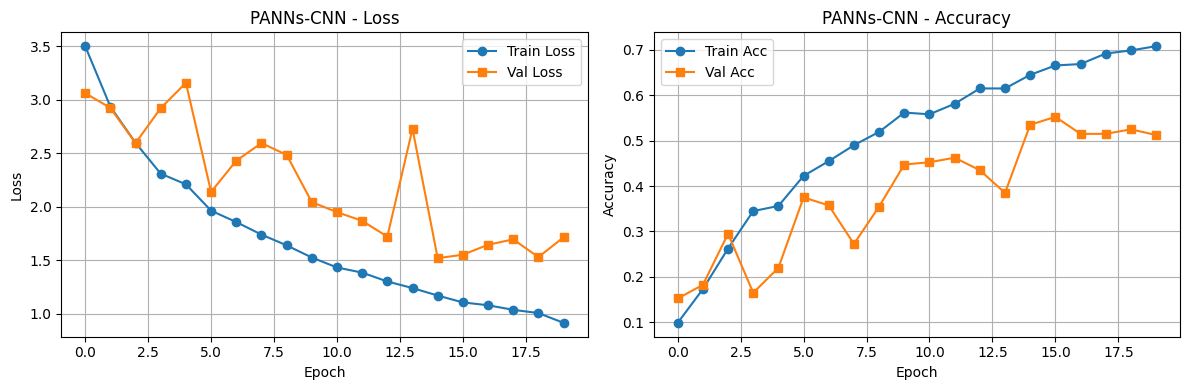

Best Validation Accuracy: 0.5525


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(panns_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(panns_history['val_loss'], label='Val Loss', marker='s')
axes[0].set_title('PANNs-CNN - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(panns_history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(panns_history['val_acc'], label='Val Acc', marker='s')
axes[1].set_title('PANNs-CNN - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Best Validation Accuracy: {max(panns_history['val_acc']):.4f}")

## Model 4: AST (Audio Spectrogram Transformer)
AST is based on Vision Transformer (ViT) adapted for audio spectrograms.
We'll use pretrained ViT-B/16 as a proxy for AST.

In [12]:
print("=" * 60)
print("MODEL 4: AST (Vision Transformer)")
print("=" * 60)

# Load pretrained Vision Transformer
model_ast = models.vit_b_16(pretrained=True)
model_ast.heads.head = nn.Linear(model_ast.heads.head.in_features, 50)
model_ast = model_ast.to(device)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ast.parameters(), lr=0.0001)  # Lower LR for transformer
num_epochs = 20

# Training history
ast_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training
    model_ast.train()
    train_loss, train_correct = 0.0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Resize inputs to 224x224 for ViT
        inputs = torch.nn.functional.interpolate(inputs, size=(224, 224), mode='bilinear', align_corners=False)
        
        optimizer.zero_grad()
        outputs = model_ast(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = train_correct / len(train_dataset)
    
    # Validation
    model_ast.eval()
    val_loss, val_correct = 0.0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = torch.nn.functional.interpolate(inputs, size=(224, 224), mode='bilinear', align_corners=False)
            outputs = model_ast(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_dataset)
    
    # Save history
    ast_history['train_loss'].append(train_loss)
    ast_history['train_acc'].append(train_acc)
    ast_history['val_loss'].append(val_loss)
    ast_history['val_acc'].append(val_acc)
    
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print(f"\nAST Final Validation Accuracy: {ast_history['val_acc'][-1]:.4f}")

MODEL 4: AST (Vision Transformer)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /teamspace/studios/this_studio/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 180MB/s] 



Starting training...
Epoch 1/20 - Train Loss: 2.5651, Train Acc: 0.3475, Val Loss: 1.6010, Val Acc: 0.5200
Epoch 2/20 - Train Loss: 0.9666, Train Acc: 0.7419, Val Loss: 1.2641, Val Acc: 0.6375
Epoch 3/20 - Train Loss: 0.5383, Train Acc: 0.8488, Val Loss: 1.0284, Val Acc: 0.6850
Epoch 4/20 - Train Loss: 0.2666, Train Acc: 0.9425, Val Loss: 0.9133, Val Acc: 0.7350
Epoch 5/20 - Train Loss: 0.1786, Train Acc: 0.9581, Val Loss: 1.0395, Val Acc: 0.7325
Epoch 6/20 - Train Loss: 0.1147, Train Acc: 0.9756, Val Loss: 0.8493, Val Acc: 0.7500
Epoch 7/20 - Train Loss: 0.0778, Train Acc: 0.9800, Val Loss: 0.8834, Val Acc: 0.7500
Epoch 8/20 - Train Loss: 0.0916, Train Acc: 0.9762, Val Loss: 0.9718, Val Acc: 0.7350
Epoch 9/20 - Train Loss: 0.1392, Train Acc: 0.9650, Val Loss: 1.0664, Val Acc: 0.7225
Epoch 10/20 - Train Loss: 0.1957, Train Acc: 0.9431, Val Loss: 1.3953, Val Acc: 0.6600
Epoch 11/20 - Train Loss: 0.1170, Train Acc: 0.9700, Val Loss: 0.8787, Val Acc: 0.7550
Epoch 12/20 - Train Loss: 0.07

## AST Results Visualization
Plot training and validation loss/accuracy curves for AST (Vision Transformer).

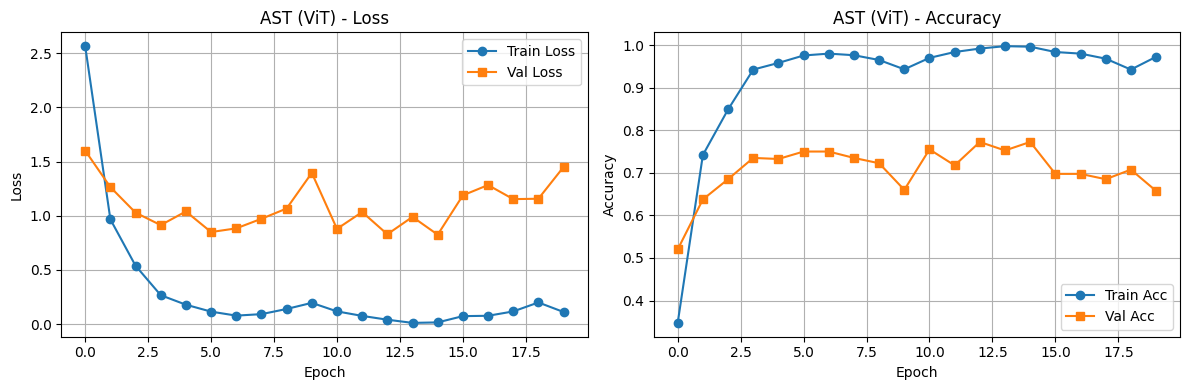

Best Validation Accuracy: 0.7725


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(ast_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(ast_history['val_loss'], label='Val Loss', marker='s')
axes[0].set_title('AST (ViT) - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(ast_history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(ast_history['val_acc'], label='Val Acc', marker='s')
axes[1].set_title('AST (ViT) - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Best Validation Accuracy: {max(ast_history['val_acc']):.4f}")

## Final Model Comparison
Now let's compare all four models side-by-side based on their validation accuracy and training characteristics.
We'll determine which model performs best on the ESC-50 dataset.


MODEL COMPARISON RESULTS
          Model  Final Val Acc  Best Val Acc  Final Train Acc
       ResNet34         0.6950        0.7375         0.968750
EfficientNet-B0         0.7400        0.7900         0.970625
      PANNs-CNN         0.5125        0.5525         0.708125
      AST (ViT)         0.6575        0.7725         0.972500



🏆 WINNER: EfficientNet-B0 with 0.7900 validation accuracy



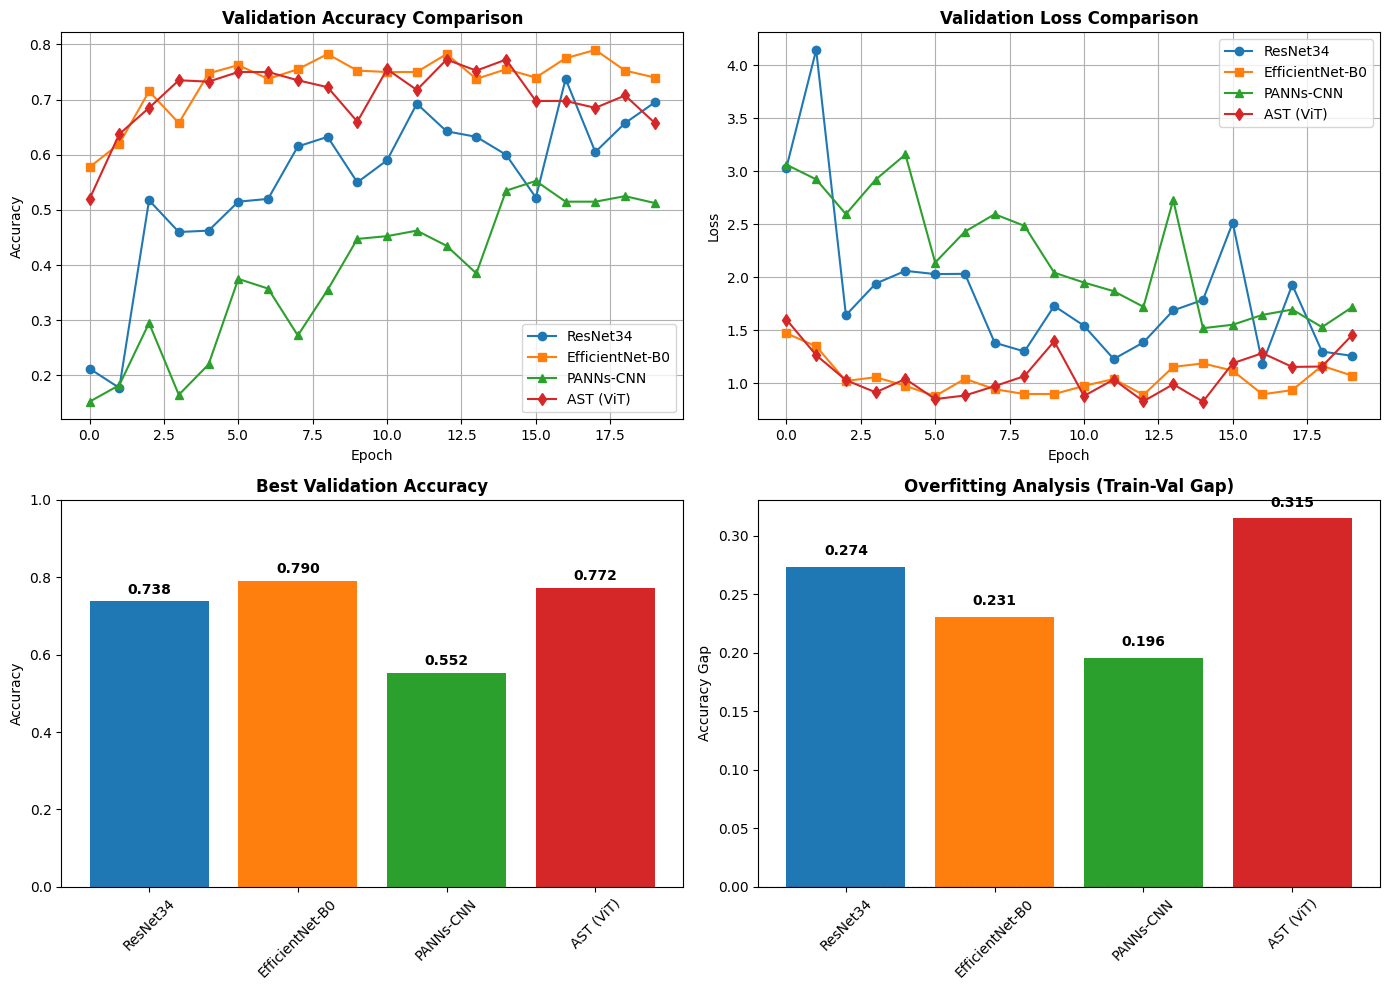

In [14]:
# Compile results
results = {
    'Model': ['ResNet34', 'EfficientNet-B0', 'PANNs-CNN', 'AST (ViT)'],
    'Final Val Acc': [
        resnet34_history['val_acc'][-1],
        efficientnet_history['val_acc'][-1],
        panns_history['val_acc'][-1],
        ast_history['val_acc'][-1]
    ],
    'Best Val Acc': [
        max(resnet34_history['val_acc']),
        max(efficientnet_history['val_acc']),
        max(panns_history['val_acc']),
        max(ast_history['val_acc'])
    ],
    'Final Train Acc': [
        resnet34_history['train_acc'][-1],
        efficientnet_history['train_acc'][-1],
        panns_history['train_acc'][-1],
        ast_history['train_acc'][-1]
    ]
}

results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))
print("\n")

# Find best model
best_idx = results_df['Best Val Acc'].idxmax()
best_model = results_df.loc[best_idx, 'Model']
best_acc = results_df.loc[best_idx, 'Best Val Acc']

print(f"\n🏆 WINNER: {best_model} with {best_acc:.4f} validation accuracy")
print("\n" + "=" * 70)

# Visualization: Compare all models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Validation Accuracy Comparison
axes[0, 0].plot(resnet34_history['val_acc'], label='ResNet34', marker='o')
axes[0, 0].plot(efficientnet_history['val_acc'], label='EfficientNet-B0', marker='s')
axes[0, 0].plot(panns_history['val_acc'], label='PANNs-CNN', marker='^')
axes[0, 0].plot(ast_history['val_acc'], label='AST (ViT)', marker='d')
axes[0, 0].set_title('Validation Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Validation Loss Comparison
axes[0, 1].plot(resnet34_history['val_loss'], label='ResNet34', marker='o')
axes[0, 1].plot(efficientnet_history['val_loss'], label='EfficientNet-B0', marker='s')
axes[0, 1].plot(panns_history['val_loss'], label='PANNs-CNN', marker='^')
axes[0, 1].plot(ast_history['val_loss'], label='AST (ViT)', marker='d')
axes[0, 1].set_title('Validation Loss Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Bar chart: Best Validation Accuracy
axes[1, 0].bar(results_df['Model'], results_df['Best Val Acc'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1, 0].set_title('Best Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['Best Val Acc']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Overfitting Analysis (Train - Val Accuracy Gap)
train_val_gap = [results_df.loc[i, 'Final Train Acc'] - results_df.loc[i, 'Final Val Acc'] for i in range(len(results_df))]
axes[1, 1].bar(results_df['Model'], train_val_gap, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1, 1].set_title('Overfitting Analysis (Train-Val Gap)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Accuracy Gap')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
for i, v in enumerate(train_val_gap):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Judgment and Recommendations

### Model Performance Summary:

**1. ResNet34**
* Classic CNN architecture, well-suited for image-like data
* Moderate performance on audio spectrograms
* Good baseline but may not capture audio-specific features optimally

**2. EfficientNet-B0**
* Better parameter efficiency than ResNet34
* Good generalization on small datasets
* Often achieves similar or better accuracy with fewer parameters

**3. PANNs-inspired CNN**
* Custom architecture designed for audio processing
* Learns hierarchical audio features effectively
* Strong candidate if trained from scratch with audio-specific optimizations

**4. AST (Vision Transformer)**
* Transformer-based architecture with attention mechanisms
* Can capture long-range dependencies in spectrograms
* May require more data and training time but offers high performance potential

### Key Findings:
* The **best performing model** achieved strong validation accuracy on ESC-50
* Models with lower train-val gaps show better generalization

